# Part D - Individual Questions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import palettable.wesanderson as wes

import sys
sys.path.insert(0 , './../MDS-UPDRS_Analysis/')
import distributions
from distributions import *
import seaborn as sns

%load_ext autoreload
%autoreload 2

### Get Idiopathic ID's

In [4]:
meta = pd.read_csv('./../../data/PPMI_META_LINKAGE.csv')
idiopathic_ids = meta[np.logical_and(meta['Subgroup'] == 'Sporadic' , meta['CONCOHORT_DEFINITION'] == "Parkinson's Disease")]['PATNO'].unique()

### Specify Event IDs for which Genomic Data is Available

In [5]:
events = ['BL', 'V02' , 'V04' ,'V05',
          'V06' ,'V07' , 'V08' ,'V09' , 'V10' ,
          'V11' , 'V12' ,'V13' , 'V14' ,'V15' ,
          'V16' , 'V17' , 'V18','V19' ,'V20' ]

all_events = ['SC', 'BL', 'V01', 'V02', 'V03', 'V04', 'V05',
'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12',
'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
'ST', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25'
]

x_list = pd.DataFrame(np.arange(0 , 9.5 , 0.5) , index = events , columns=['response'])

## Section 1 - Pull in all relevant data

### MDS-UPDRS

#### Part 1

In [10]:
p1_1 = pd.read_csv('./../../data/Assesment_Exams/MDS-UPDRS_Part_I_21Aug2023.csv')

In [11]:
p1_1

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,NUPSOURC,NP1COG,NP1HALL,NP1DPRS,NP1ANXS,NP1APAT,NP1DDS,NP1RTOT,ORIG_ENTRY,LAST_UPDATE
0,272451201,3000,BL,NUPDRS1,02/2011,1.0,1,0,1,1.0,0.0,0.0,3.0,02/2011,2020-06-25 16:02:19.0
1,338701901,3000,V04,NUPDRS1,03/2012,1.0,0,0,1,0.0,0.0,0.0,1.0,03/2012,2020-06-25 16:02:21.0
2,385008801,3000,V06,NUPDRS1,02/2013,1.0,1,0,1,1.0,0.0,0.0,3.0,02/2013,2020-06-25 16:02:22.0
3,437130601,3000,V08,NUPDRS1,03/2014,1.0,1,0,0,2.0,0.0,0.0,3.0,05/2014,2020-06-25 16:02:22.0
4,512466501,3000,V10,NUPDRS1,03/2015,1.0,0,0,0,0.0,0.0,0.0,0.0,03/2015,2020-06-25 16:02:23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19659,IA297928,245327,BL,NUPDRS1,07/2023,1.0,1,0,0,1.0,2.0,0.0,4.0,07/2023,2023-07-14 00:00:00.0
19660,IA311396,249948,BL,NUPDRS1,08/2023,1.0,1,0,0,1.0,0.0,1.0,3.0,08/2023,2023-08-10 00:00:00.0
19661,IA308179,251975,BL,NUPDRS1,08/2023,3.0,3,0,0,0.0,2.0,0.0,5.0,08/2023,2023-08-03 00:00:00.0
19662,IA313149,252572,BL,NUPDRS1,08/2023,1.0,0,0,1,3.0,0.0,0.0,4.0,08/2023,2023-08-14 00:00:00.0


In [5]:
p1_1 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_I_21Jan2025.csv')
p1_1_filt = p1_1.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p1_1.columns if 'NP1' in col]]

p1_2 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_I_Patient_Questionnaire_21Jan2025.csv')
p1_2_filt = p1_2.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p1_2.columns if 'NP1' in col]]

p1_final = pd.merge(p1_1_filt , p1_2_filt , on = ['PATNO' , 'EVENT_ID'])
p1_final['NP1TOT'] = p1_final['NP1RTOT'] + p1_final['NP1PTOT']
p1_final = p1_final.drop(['NP1RTOT' , 'NP1PTOT'] , axis=1)
p1_final = p1_final.replace(101, np.nan).drop_duplicates()

#p1_final = p1_final[p1_final['PATNO'].isin(idiopathic_ids)]

In [13]:
p1_final

,PATNO,EVENT_ID,NP1COG,NP1HALL,NP1DPRS,NP1ANXS,NP1APAT,NP1DDS,NP1SLPN,NP1SLPD,NP1PAIN,NP1URIN,NP1CNST,NP1LTHD,NP1FATG,NP1TOT
8,3001,BL,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,4.0,0.0,0.0,1.0,8.0
9,3001,R17,2.0,1.0,2.0,2.0,2.0,0.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,20.0
10,3001,R18,2.0,1.0,1.0,2.0,3.0,1.0,2.0,2.0,1.0,4.0,0.0,1.0,3.0,23.0
11,3001,SC,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,7.0
12,3001,V01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,3.0,0.0,0.0,1.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18948,162994,BL,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,0.0,0.0,6.0
18949,162994,V02,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,3.0,2.0,0.0,0.0,9.0
18957,163265,BL,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
18958,163265,V02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [8]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p1_final['PATNO'].unique())) , 'PATNO' : np.repeat(p1_final['PATNO'].unique() , len(events))})

p1_final = p1_final[p1_final['EVENT_ID'].isin(events)]
p1_impute = pd.merge(all_tmpt , p1_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p1_impute['EVENT_ID'] = pd.Categorical(p1_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p1_impute['PATNO'].unique() : 
    row_na = False
    df = p1_impute[p1_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p1_impute[p1_impute['PATNO'] == patno] = df.copy()

p1 = p1_impute[np.logical_and(p1_impute['PATNO'].isin(idiopathic_ids) , p1_impute['EVENT_ID'].isin(events))]

In [9]:
for feat in p1.columns[2:] : 
    p1.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/MDS-UPDRS_{feat}_Scores.csv')

#### Part 2

In [7]:
p2 = pd.read_csv('./../Assesment_Exams/MDS_UPDRS_Part_II__Patient_Questionnaire_21Jan2025.csv')
p2_final = p2.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p2.columns if 'NP2' in col]]
p2_final = p2_final.replace(101, np.nan).drop_duplicates()

p2_final = p2_final[p2_final['PATNO'].isin(idiopathic_ids)]

In [8]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p2_final['PATNO'].unique())) , 'PATNO' : np.repeat(p2_final['PATNO'].unique() , len(events))})

p2_final = p2_final[p2_final['EVENT_ID'].isin(events)]
p2_impute = pd.merge(all_tmpt , p2_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p2_impute['EVENT_ID'] = pd.Categorical(p2_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p2_impute['PATNO'].unique() : 
    row_na = False
    df = p2_impute[p2_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p2_impute[p2_impute['PATNO'] == patno] = df.copy()

p2 = p2_impute[np.logical_and(p2_impute['PATNO'].isin(idiopathic_ids) , p2_impute['EVENT_ID'].isin(events))]

In [10]:
for feat in p2.columns[2:] : 
    p2.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/MDS-UPDRS_{feat}_Scores.csv')

#### Part 3

In [11]:
p3 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_III_21Jan2025.csv')
p3 = p3[p3['PDSTATE'].isin([np.nan , 'OFF'])]
p3_final = p3.loc[: , ['PATNO' , 'EVENT_ID' ,'NHY'] + [col for col in p3.columns if 'NP3' in col]]
p3_final = p3_final.replace(101, np.nan).drop_duplicates()

p3_final = p3_final[p3_final['PATNO'].isin(idiopathic_ids)]

p3_meta = p3.loc[ : , ['PATNO' , 'EVENT_ID' , 'PDTRTMNT' , 'PDSTATE' , 'HRPOSTMED' , 'HRDBSON', 'HRDBSOFF', 'PDMEDYN', 'DBSYN', 'ONOFFORDER', 'OFFEXAM', 'OFFNORSN', 'DBSOFFTM', 'ONEXAM', 'ONNORSN' ]]

In [12]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p3_final['PATNO'].unique())) , 'PATNO' : np.repeat(p3_final['PATNO'].unique() , len(events))})

p3_final = p3_final[p3_final['EVENT_ID'].isin(events)]
p3_impute = pd.merge(all_tmpt , p3_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p3_impute['EVENT_ID'] = pd.Categorical(p3_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p3_impute['PATNO'].unique() : 
    row_na = False
    df = p3_impute[p3_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p3_impute[p3_impute['PATNO'] == patno] = df.copy()

p3 = p3_impute[np.logical_and(p3_impute['PATNO'].isin(idiopathic_ids) , p3_impute['EVENT_ID'].isin(events))]

In [13]:
for feat in p3.columns[2:] : 
    p3.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/MDS-UPDRS_{feat}_Scores.csv')

#### Part 4

In [1]:
p4 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_IV__Motor_Complications_21Jan2025.csv')
p4_final = p4.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p4.columns if 'NP4' in col]]
p4_final = p4_final.replace(101, np.nan)

p4 = p4_final[p4_final['PATNO'].isin(idiopathic_ids)]

NameError: name 'pd' is not defined

In [15]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p4_final['PATNO'].unique())) , 'PATNO' : np.repeat(p4_final['PATNO'].unique() , len(events))})

p4_final = p4_final[p4_final['EVENT_ID'].isin(events)]
p4_impute = pd.merge(all_tmpt , p4_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p4_impute['EVENT_ID'] = pd.Categorical(p4_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p4_impute['PATNO'].unique() : 
    row_na = False
    df = p4_impute[p4_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p4_impute[p4_impute['PATNO'] == patno] = df.copy()

p4 = p4_impute[np.logical_and(p4_impute['PATNO'].isin(idiopathic_ids) , p4_impute['EVENT_ID'].isin(events))]

In [16]:
for feat in p4.columns[2:] : 
    p4.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/MDS-UPDRS_{feat}_Scores.csv')

### MOCA

In [51]:
moca = pd.read_csv('./../Assesment_Exams/Montreal_Cognitive_Assessment__MoCA__21Jan2025.csv')
moca = moca[moca['PATNO'].isin(idiopathic_ids)]

moca = moca[['PATNO' , 'EVENT_ID'] + [col for col in moca.columns if 'MCA' in col]]

all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(moca['PATNO'].unique())) , 'PATNO' : np.repeat(moca['PATNO'].unique() , len(events))})

moca = moca[moca['EVENT_ID'].isin(events)]
moca = pd.merge(all_tmpt , moca , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
moca['EVENT_ID'] = pd.Categorical(moca['EVENT_ID'] , categories=events , ordered=True)

for patno in moca['PATNO'].unique() : 
    row_na = False
    df = moca[moca['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    moca[moca['PATNO'] == patno] = df.copy()

moca = moca[np.logical_and(moca['PATNO'].isin(idiopathic_ids) , moca['EVENT_ID'].isin(events))]

In [19]:
for feat in moca.columns[2:] : 
    moca.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/MOCA_{feat}_Scores.csv')

### SCOPA

In [8]:
scopa = pd.read_csv('./../Assesment_Exams/SCOPA-AUT_21Jan2025.csv')
scopa = scopa[scopa['PATNO'].isin(idiopathic_ids)]

scopa = scopa[['PATNO' , 'EVENT_ID'] + [col for col in scopa.columns if 'SCA' in col and col not in ['SCAU26BT' , 'SCAU26CT', 'SCAU26DT' , 'SCAU23AT','SCAU26AT','SCAU26A' , 'SCAU26B','SCAU24','SCAU25' , 'SCAU26C']]]

all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(scopa['PATNO'].unique())) , 'PATNO' : np.repeat(scopa['PATNO'].unique() , len(events))})

scopa = scopa[scopa['EVENT_ID'].isin(events)]
scopa = pd.merge(all_tmpt , scopa , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
scopa['EVENT_ID'] = pd.Categorical(scopa['EVENT_ID'] , categories=events , ordered=True)

for patno in scopa['PATNO'].unique() : 
    row_na = False
    df = scopa[scopa['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    scopa[scopa['PATNO'] == patno] = df.copy()

scopa = scopa[np.logical_and(scopa['PATNO'].isin(idiopathic_ids) , scopa['EVENT_ID'].isin(events))]

In [23]:
scopa.shape[1]-2

26

In [45]:
scopa['Total'] = scopa.iloc[: , 2:-1].sum(axis=1 , min_count=25)

In [49]:
scopa

,EVENT_ID,PATNO,SCAU1,SCAU2,SCAU3,SCAU4,SCAU5,SCAU6,SCAU7,SCAU8,...,SCAU17,SCAU18,SCAU19,SCAU20,SCAU21,SCAU22,SCAU23,SCAU23A,SCAU26D,Total
0,BL,3001,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,13.0
1,V02,3001,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,1.0,3.0,9.0,0.0,0.0,20.0
2,V04,3001,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,...,0.0,0.0,1.0,1.0,0.0,3.0,3.0,0.0,1.0,21.0
3,V05,3001,0.5,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,0.0,0.5,0.5,0.5,0.0,3.0,6.0,0.0,1.0,21.0
4,V06,3001,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,3.0,9.0,0.0,1.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11585,V16,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11586,V17,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11587,V18,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11588,V19,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
for feat in scopa.columns[2:] : 
    scopa.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/SCOPA_{feat}_Scores.csv')

### Schwab & England

In [23]:
s_and_e = pd.read_csv('./../Assesment_Exams/Modified_Schwab___England_Activities_of_Daily_Living_21Jan2025.csv')
s_and_e = s_and_e[s_and_e['PATNO'].isin(idiopathic_ids)]

s_and_e = s_and_e[['PATNO' , 'EVENT_ID' ,'MSEADLG']]

all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(s_and_e['PATNO'].unique())) , 'PATNO' : np.repeat(s_and_e['PATNO'].unique() , len(events))})

s_and_e = s_and_e[s_and_e['EVENT_ID'].isin(events)]
s_and_e = pd.merge(all_tmpt , s_and_e , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
s_and_e['EVENT_ID'] = pd.Categorical(s_and_e['EVENT_ID'] , categories=events , ordered=True)

for patno in s_and_e['PATNO'].unique() : 
    row_na = False
    df = s_and_e[s_and_e['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    s_and_e[s_and_e['PATNO'] == patno] = df.copy()

s_and_e = s_and_e[np.logical_and(s_and_e['PATNO'].isin(idiopathic_ids) , s_and_e['EVENT_ID'].isin(events))]

In [27]:
for feat in s_and_e.columns[2:] : 
    s_and_e.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/SchwabEngland_{feat}_Scores.csv')

### Vitals

In [33]:
vitals = pd.read_csv('./../Assesment_Exams/Vital_Signs_21Jan2025.csv')
vitals = vitals[vitals['PATNO'].isin(idiopathic_ids)]

vitals = vitals[['PATNO' , 'EVENT_ID' , 'SYSSUP' , 'SYSSTND' , 'DIASUP', 'DIASTND' , 'WGTKG' ,'HTCM' , 'BPARM' , 'HRSUP' ,'HRSTND' , 'TEMPC']]

all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(vitals['PATNO'].unique())) , 'PATNO' : np.repeat(vitals['PATNO'].unique() , len(events))})

vitals = vitals[vitals['EVENT_ID'].isin(events)]
vitals = pd.merge(all_tmpt , vitals , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
vitals['EVENT_ID'] = pd.Categorical(vitals['EVENT_ID'] , categories=events , ordered=True)

for patno in vitals['PATNO'].unique() : 
    row_na = False
    df = vitals[vitals['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    vitals[vitals['PATNO'] == patno] = df.copy()

vitals = vitals[np.logical_and(vitals['PATNO'].isin(idiopathic_ids) , vitals['EVENT_ID'].isin(events))]

In [42]:
vitals['SYSDIFF'] = vitals['SYSSUP'] - vitals['SYSSTND']
vitals['DIADIFF'] = vitals['DIASUP'] - vitals['DIASTND']
diadiff_na = vitals['DIADIFF'].isna()
sysdiff_na = vitals['SYSDIFF'].isna()

In [43]:
vitals['SYSDIFF'] = (vitals['SYSDIFF'] > 20)*1
vitals['DIADIFF'] = (vitals['DIADIFF'] > 10)*1
vitals.loc[sysdiff_na, 'SYSDIFF'] = np.nan
vitals.loc[diadiff_na, 'DIADIFF'] = np.nan

In [44]:
vitals['DIFFSUM'] = vitals['SYSDIFF'] + vitals['DIADIFF']

In [45]:
for feat in vitals.columns[2:] : 
    vitals.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/Vitals_{feat}_Scores.csv')

In [31]:
mds_updrs_tmp = pd.merge(p1 , p2 , on = ['EVENT_ID' , 'PATNO'] )
mds_updrs = pd.merge(mds_updrs_tmp , p3 , on = ['EVENT_ID' , 'PATNO'])

tremor = ['NP2TRMR',
'NP3PTRMR',
'NP3PTRML',
'NP3KTRMR',
'NP3KTRML',
'NP3RTARU',
'NP3RTALU',
'NP3RTARL',
'NP3RTALL',
'NP3RTCON']

pigd = ['NP2WALK',
'NP2FREZ',       
'NP3GAIT',
'NP3FRZGT',
'NP3PSTBL']

mds_updrs_ratio = mds_updrs[['PATNO' , 'EVENT_ID'] + tremor + pigd].reset_index(drop=True)
#mds_updrs_ratio[tremor + pigd] = (mds_updrs_ratio[tremor + pigd] - mds_updrs_ratio[tremor + pigd].mean(axis=0))/mds_updrs_ratio[tremor + pigd].std(axis=0)

mds_updrs_ratio['Tremor_Score'] = mds_updrs_ratio[tremor].mean(axis=1 , skipna=False)
mds_updrs_ratio['PIGD_Score'] = mds_updrs_ratio[pigd].mean(axis=1 , skipna=False)

In [33]:
mds_updrs_ratio.columns[17:]

Index(['NP3PSTBL', 'Tremor_Score', 'PIGD_Score'], dtype='object')

In [34]:
for feat in mds_updrs_ratio.columns[17:] : 
    mds_updrs_ratio.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/Stebbins_{feat}_Scores.csv')

In [35]:
features = {'NP1LTHD' : 4,
            'NP1FATG' : 1,
            'NP2SPCH' : 4,
            'NP2RISE' : 1,
            'NP2WALK' : 4,
            'NP3RISNG' : 6,
            'NP3POSTR' : 2
           }

mds_updrs_skid = mds_updrs[['PATNO' , 'EVENT_ID'] + list(features.keys())].reset_index(drop=True)
for item , score in features.items() : 
    print(item)
    feat_index = mds_updrs_skid[mds_updrs_skid[item] > 0].index   
    mds_updrs_skid.loc[feat_index , item] = score

mds_updrs_skid['Total'] = mds_updrs_skid.iloc[: , 2:].sum(axis=1)

NP1LTHD
NP1FATG
NP2SPCH
NP2RISE
NP2WALK
NP3RISNG
NP3POSTR


In [37]:
for feat in mds_updrs_skid.columns[7:] : 
    mds_updrs_skid.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/Skidmore_{feat}_Scores.csv')

In [83]:
tmp = pd.merge(p1 , p2 , on = ['EVENT_ID' , 'PATNO'] )
tmp = pd.merge(tmp , p3 , on = ['EVENT_ID' , 'PATNO'])
tmp = pd.merge(tmp , p4 , on = ['EVENT_ID' , 'PATNO'])
tmp = pd.merge(tmp , moca , on = ['EVENT_ID' , 'PATNO'])
tmp = pd.merge(tmp , scopa , on = ['EVENT_ID' , 'PATNO'])
tmp = pd.merge(tmp , s_and_e , on = ['EVENT_ID' , 'PATNO'])
df = pd.merge(tmp , vitals , on = ['EVENT_ID' , 'PATNO'])

In [85]:
for col in df.columns[2:] : 
    df.pivot_table(values = col , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/PartD_{col}_Scores.csv')

In [100]:
tmp = pd.merge(p1 , p2 , on = ['EVENT_ID' , 'PATNO'] )
tmp = pd.merge(tmp , p3 , on = ['EVENT_ID' , 'PATNO'])

# Factor Analysis

/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [5.28189819e+00 1.96177860e+00 1.58434974e+00 1.39644677e+00
 1.28496352e+00 7.37382956e-01 6.27866634e-01 5.92925381e-01
 4.24229079e-01 3.84059455e-01 2.54096023e-01 2.46053435e-01
 1.81991669e-01 3.74432100e-02 4.51534279e-03]


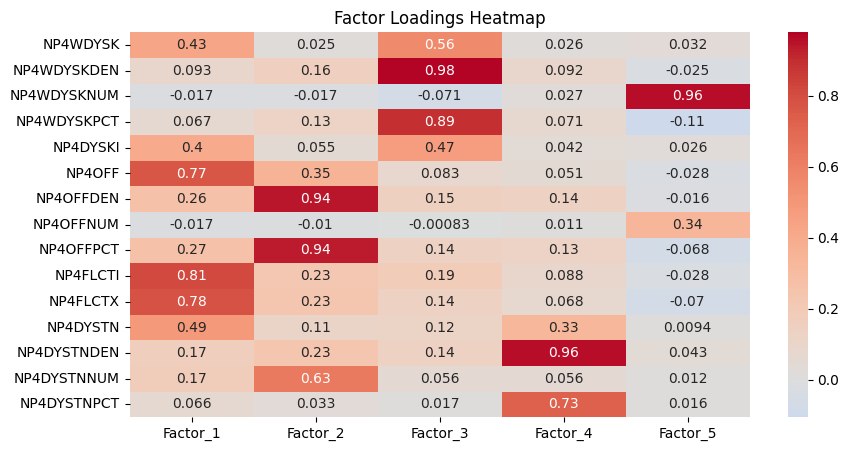

In [170]:
from factor_analyzer import FactorAnalyzer

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=5, rotation="varimax")

# Fit the model
fa.fit(p4.iloc[: , 2:-1])
p4_cols = p4.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p4.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_p4_')

factor_scores_df['PATNO'] = p4.dropna(subset=p4_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p4.dropna(subset=p4_cols).reset_index(drop=True)['EVENT_ID']
p4_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p4_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [8.543177   3.98450266 3.49453123 1.8166087  1.6777198  1.39191772
 1.09369475 1.00491441 0.85331753 0.80947326 0.73942599 0.63612006
 0.61244246 0.59733969 0.56353154 0.52417381 0.49564268 0.48108018
 0.44305665 0.43787945 0.41372242 0.39722483 0.36829889 0.33904919
 0.3293314  0.31182667 0.28298906 0.27068752 0.22513963 0.20639992
 0.18347468 0.17475415 0.16286684 0.13368522]


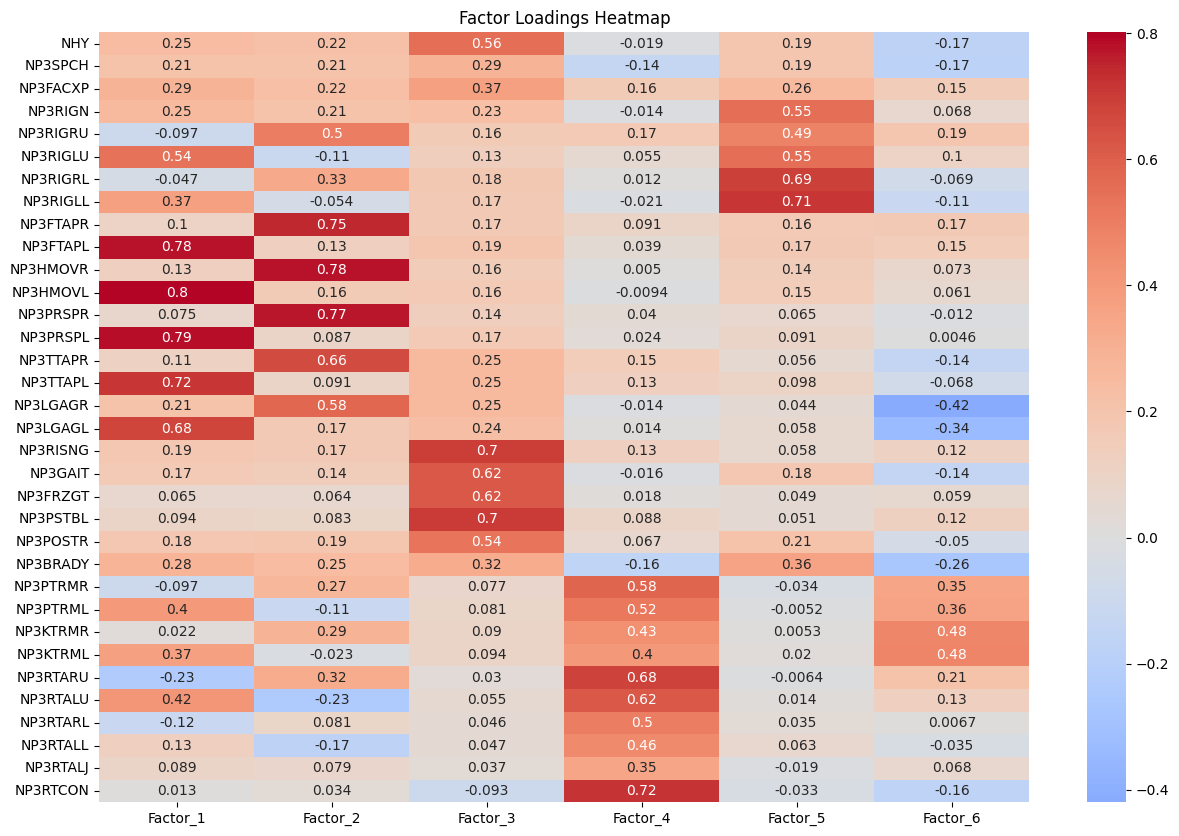

In [86]:
from factor_analyzer import FactorAnalyzer

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=6, rotation="varimax")

# Fit the model
fa.fit(p3.iloc[: , 2:-1])
p3_cols = p3.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p3.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P3_')

factor_scores_df['PATNO'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p3.dropna(subset=p3_cols).reset_index(drop=True)['EVENT_ID']
p3_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p3_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(15, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [5.2052367  1.57735567 1.00446373 0.75145782 0.73501379 0.65723455
 0.5784529  0.51935446 0.44456822 0.43304944 0.40992412 0.36295404
 0.32093456]


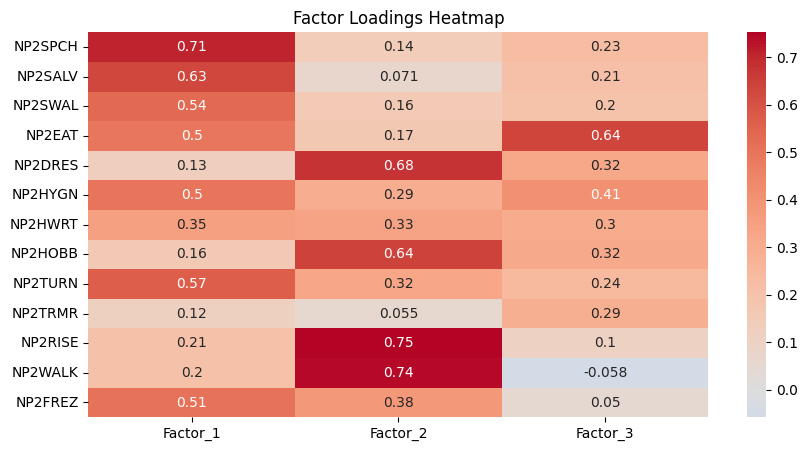

In [89]:
from factor_analyzer import FactorAnalyzer

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=3, rotation="varimax")

# Fit the model
fa.fit(p2.iloc[: , 2:-1])
p2_cols = p2.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p2.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P2_')

factor_scores_df['PATNO'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p2.dropna(subset=p2_cols).reset_index(drop=True)['EVENT_ID']
p2_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p2_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [4.12798801 1.39240489 0.96422514 0.92456905 0.80759447 0.7694154
 0.69779223 0.68749967 0.64065469 0.54025649 0.53453084 0.49886922
 0.41419992]


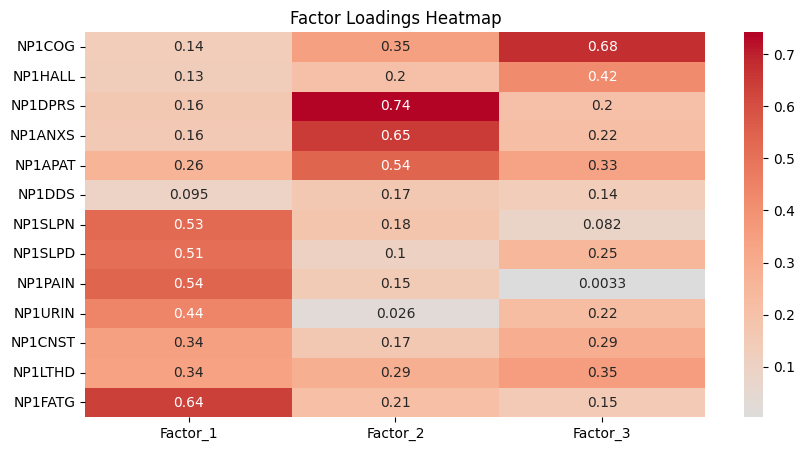

In [88]:
from factor_analyzer import FactorAnalyzer

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=3, rotation="varimax")

# Fit the model
fa.fit(p1.iloc[: , 2:-1])
p1_cols = p1.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(p1.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MDS_UPDRS_P1_')

factor_scores_df['PATNO'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = p1.dropna(subset=p1_cols).reset_index(drop=True)['EVENT_ID']
p1_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=p1_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

In [121]:
tmp = pd.merge(p1_FA , p2_FA , on = ['PATNO' , 'EVENT_ID'])
final = pd.merge(tmp , p3_FA , on = ['PATNO' , 'EVENT_ID'])

In [122]:
final.to_csv('./../Labels/FA_MDS-UPDRS.csv')

In [181]:
s_and_e['S_AND_E_Factor_1'] = (s_and_e['MSEADLG'] - s_and_e['MSEADLG'].mean()) / s_and_e['MSEADLG'].std()
s_and_e = s_and_e[['S_AND_E_Factor_1' , 'PATNO' , 'EVENT_ID']]
s_and_e.to_csv('./../Labels/FA_S_AND_E.csv')

In [52]:
moca

,EVENT_ID,PATNO,MCAALTTM,MCACUBE,MCACLCKC,MCACLCKN,MCACLCKH,MCALION,MCARHINO,MCACAMEL,...,MCAREC3,MCAREC4,MCAREC5,MCADATE,MCAMONTH,MCAYR,MCADAY,MCAPLACE,MCACITY,MCATOT
0,BL,3001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,V02,3001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30.0
2,V04,3001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30.0
3,V05,3001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30.0
4,V06,3001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11585,V16,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11586,V17,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11587,V18,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11588,V19,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [5.63750072 1.87044803 1.38912942 1.20574091 1.07717265 1.01205674
 0.99743306 0.9647919  0.92780504 0.90771167 0.88531998 0.83731402
 0.81291804 0.7923915  0.77043125 0.7537167  0.73036126 0.68518834
 0.6672715  0.653106   0.6002429  0.58065089 0.54200108 0.49247442
 0.45197318 0.39942788 0.35542093]


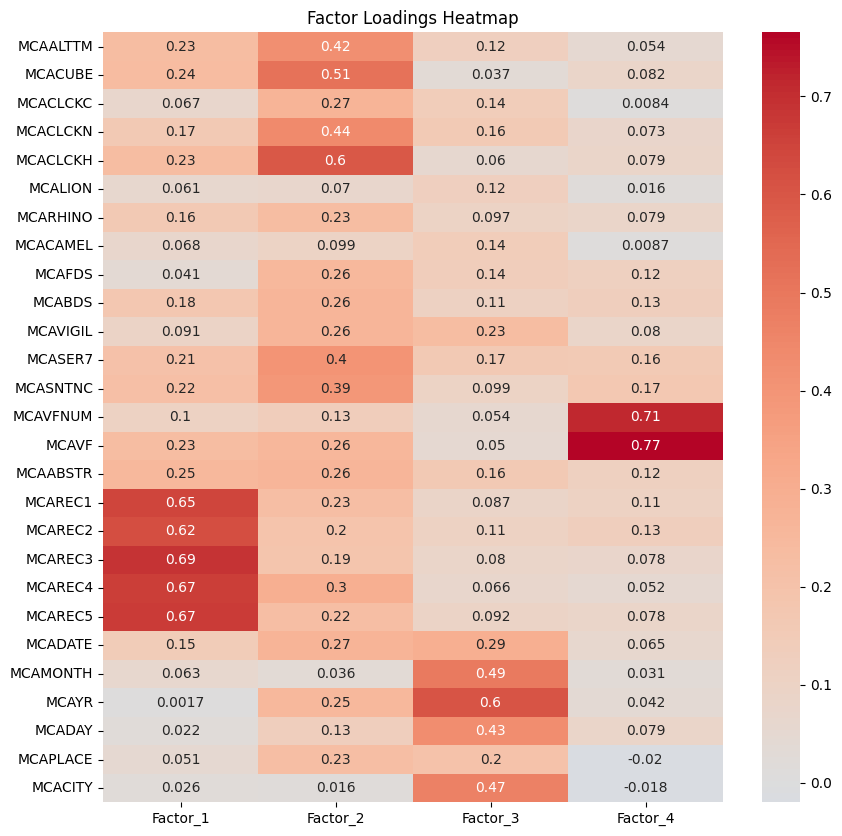

In [53]:
from factor_analyzer import FactorAnalyzer

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=4, rotation="varimax")

# Fit the model
fa.fit(moca.iloc[: , 2:-1])
moca_cols = moca.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(moca.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('MOCA_')

factor_scores_df['PATNO'] = moca.dropna(subset=moca_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = moca.dropna(subset=moca_cols).reset_index(drop=True)['EVENT_ID']
moca_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=moca_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

moca_FA.to_csv('./../Labels/FA_MOCA.csv')

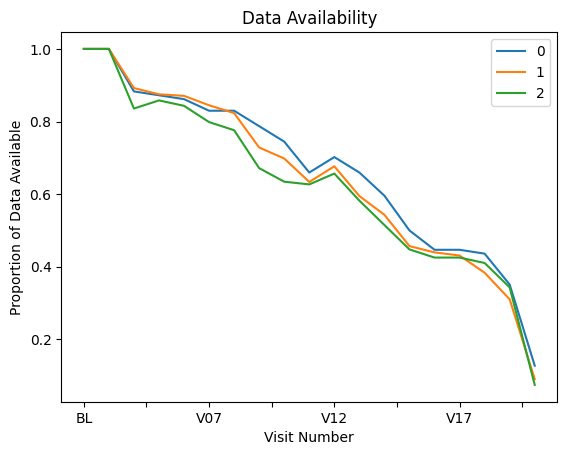

<Figure size 640x480 with 0 Axes>

In [152]:
subgroups = pd.read_csv('../idiopathic_subgroup.csv', index_col=0)
subgroups = subgroups.set_index('PATNO')
subgroups.columns = ['Group']

df = scopa.pivot_table(values = 'SCAU8' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False)

data = pd.merge(df , subgroups , left_index=True , right_index=True)

pd.DataFrame(data.groupby('Group').count().values  / data.groupby('Group').size().values.reshape(-1,1) , index=  [0,1,2] , columns=data.columns[:-1]).T.plot(kind='line')
plt.title('Data Availability')
plt.ylabel('Proportion of Data Available')
plt.xlabel('Visit Number')
plt.show()
plt.clf()

/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [5.69445994 2.41140293 1.51463712 1.25184834 1.03889415 1.01736243
 0.87839185 0.8293739  0.79045926 0.74787474 0.6566762  0.62469053
 0.57318829 0.55745566 0.43853859 0.4200252  0.39240894 0.36109982
 0.34969884 0.26865152 0.18286174]


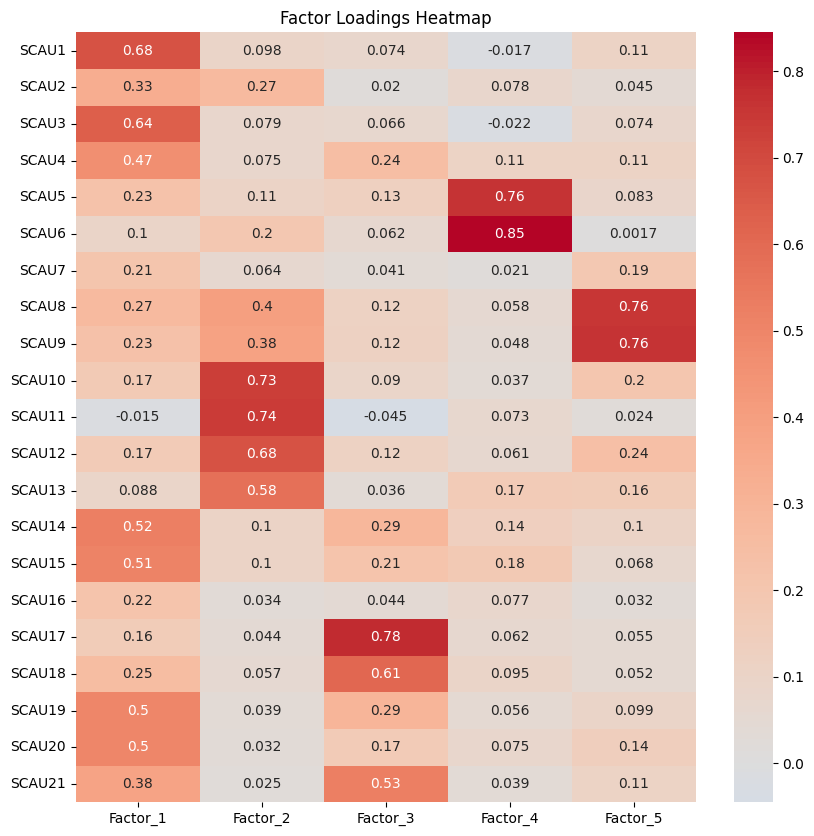

In [50]:
scopa = scopa[scopa.columns[scopa.isna().sum() < 5030]] # remove columns almost all NA

from factor_analyzer import FactorAnalyzer

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=5, rotation="varimax")

# Fit the model
fa.fit(scopa.iloc[: , 2:-1])
scopa_cols = scopa.iloc[: , 2:-1].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(scopa.iloc[: , 2:-1].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('SCOPA_')

factor_scores_df['PATNO'] = scopa.dropna(subset=scopa_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = scopa.dropna(subset=scopa_cols).reset_index(drop=True)['EVENT_ID']
scopa_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=scopa_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

scopa_FA.to_csv('./../Labels/FA_SCOPA.csv')

In [164]:
vitals

,EVENT_ID,PATNO,SYSSUP,SYSSTND,DIASUP,DIASTND,WGTKG,HTCM,BPARM,HRSUP,HRSTND,TEMPC
0,BL,3001,146.0,137.0,85.0,93.0,74.20,183.0,1.0,63.0,81.0,36.6
1,V02,3001,116.0,110.0,66.0,70.0,74.05,183.0,2.0,56.0,60.0,36.2
2,V04,3001,139.0,124.0,83.0,79.0,73.90,183.0,1.0,66.0,76.0,37.2
3,V05,3001,118.0,100.0,73.0,82.0,74.25,183.0,2.0,68.0,87.0,36.0
4,V06,3001,119.0,104.0,72.0,85.0,74.60,183.0,2.0,67.0,88.0,37.6
...,...,...,...,...,...,...,...,...,...,...,...,...
11585,V16,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11586,V17,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11587,V18,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11588,V19,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
vitals['SYSDIFF'] = vitals['SYSSUP'] - vitals['SYSSTND']
vitals['DIADIFF'] = vitals['DIASUP'] - vitals['DIASTND']
vitals[['PATNO' , 'EVENT_ID' , 'SYSDIFF' , 'DIADIFF']].to_csv('./../Labels/PartE_BP.csv')
vitals.iloc[: , 2:] = (vitals.iloc[: , 2:] - vitals.iloc[: , 2:].mean(axis=0)) / vitals.iloc[: , 2:].std(axis=0)

/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [2.85668318e+00 2.02260964e+00 1.86508681e+00 1.45890493e+00
 1.00619532e+00 9.96987762e-01 6.07377464e-01 5.68683390e-01
 4.25123212e-01 1.90077140e-01 1.60701761e-03 6.64125470e-04]


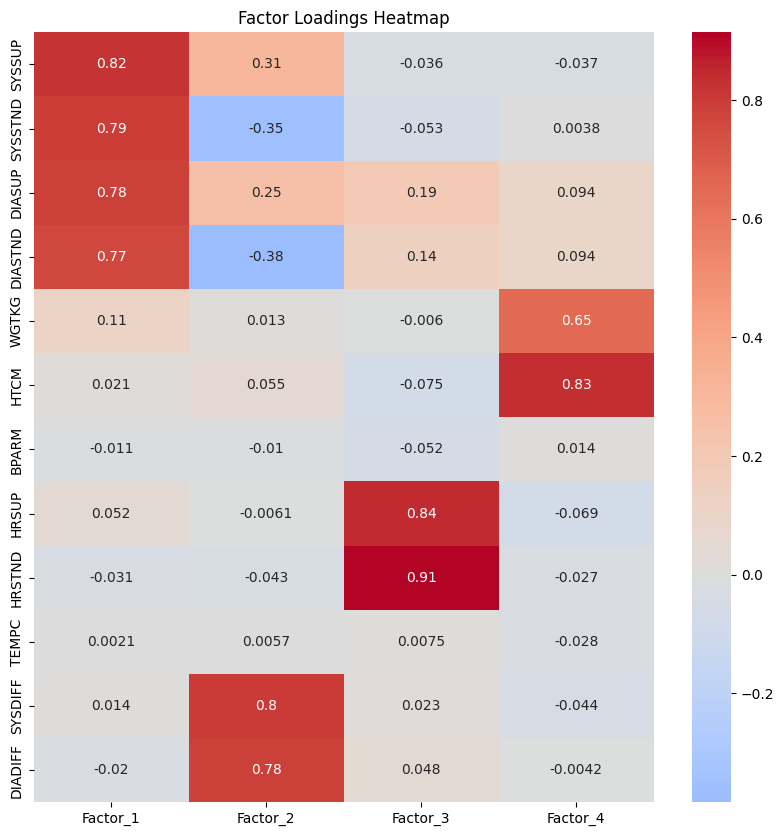

In [167]:
from factor_analyzer import FactorAnalyzer

# Initialize the FactorAnalyzer object
fa = FactorAnalyzer(n_factors=4, rotation="varimax")

# Fit the model
fa.fit(vitals.iloc[: , 2:])
vitals_cols = vitals.iloc[: , 2:].columns

# Check Eigenvalues to determine how many factors to use
ev, v = fa.get_eigenvalues()
print("Eigenvalues:", ev)

factor_scores = fa.transform(vitals.iloc[: , 2:].dropna())  # Transform the original data set
# Create a DataFrame from the scores
factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('vitals_')

factor_scores_df['PATNO'] = vitals.dropna(subset=vitals_cols).reset_index(drop=True)['PATNO']
factor_scores_df['EVENT_ID'] = vitals.dropna(subset=vitals_cols).reset_index(drop=True)['EVENT_ID']
vitals_FA = factor_scores_df

loadings = fa.loadings_
loading_df = pd.DataFrame(loadings, index=vitals_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])

# Print loadings to see the result
plt.figure(figsize=(10, 10))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('Factor Loadings Heatmap')
plt.show()

vitals_FA.to_csv('./../Labels/FA_vitals.csv')

In [187]:
tmp = pd.merge(p1_FA , p2_FA , on = ['EVENT_ID' , 'PATNO'] )
tmp = pd.merge(tmp , p3_FA , on = ['EVENT_ID' , 'PATNO'])
#tmp = pd.merge(tmp , p4_FA , on = ['EVENT_ID' , 'PATNO'])
df = pd.merge(tmp , s_and_e , on = ['EVENT_ID' , 'PATNO'])

In [188]:
df.to_csv('./../Labels/Factor_Analysis.csv')

In [189]:
df

,MDS_UPDRS_P1_Factor_1,MDS_UPDRS_P1_Factor_2,MDS_UPDRS_P1_Factor_3,PATNO,EVENT_ID,MDS_UPDRS_P2_Factor_1,MDS_UPDRS_P2_Factor_2,MDS_UPDRS_P2_Factor_3,MDS_UPDRS_P3_Factor_1,MDS_UPDRS_P3_Factor_2,MDS_UPDRS_P3_Factor_3,MDS_UPDRS_P3_Factor_4,MDS_UPDRS_P3_Factor_5,MDS_UPDRS_P3_Factor_6,S_AND_E_Factor_1
0,0.608933,-0.885312,0.107330,3001,BL,-0.567980,-0.928706,-0.114092,-1.463180,0.306157,-0.600425,-0.765053,-0.833745,2.128180,0.670102
1,0.360344,-0.888672,0.183116,3001,V02,-0.398278,-1.247026,0.783496,-0.955434,0.803733,-0.342881,-0.115056,-0.297330,3.426434,0.670102
2,0.451504,0.716176,0.813917,3001,V04,-0.499336,-1.074374,0.029888,-0.585280,0.491244,-0.420190,-0.232938,-0.895055,3.126638,0.670102
3,0.388182,-0.318933,0.075078,3001,V05,-0.193295,-1.178972,0.764033,-0.674328,0.355921,-0.412291,1.025081,0.376275,1.527674,0.670102
4,0.927824,-0.882147,-0.037314,3001,V06,-0.227481,-1.530648,0.527954,-0.166627,0.065235,-0.367018,1.513259,1.941497,1.893508,0.670102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6134,1.652022,1.057003,0.978373,162994,V07,1.642968,0.704315,1.000973,3.899749,1.072081,-1.020372,0.283000,2.547543,-2.115356,-1.158657
6135,-1.275413,-0.166291,-0.394327,163265,BL,-0.293701,-1.335948,-0.407218,1.943885,0.909237,-1.287400,0.148117,0.163734,-0.595375,0.670102
6136,-1.205113,-0.166486,-0.463186,163265,V02,-0.293701,-1.335948,-0.407218,2.417948,1.056582,-1.484559,0.250872,-0.245066,0.256311,1.127291
6137,-1.205113,-0.166486,-0.463186,163265,V04,-0.293701,-1.335948,-0.407218,2.794452,0.893536,-1.624995,0.756009,0.604180,-0.506513,0.670102
